# **08 · 페르소나 프로파일 전수 — 저다양 2유형은 '고령·TV 단일 채널'이라는 뚜렷한 얼굴을 가진다**

### **"4유형 × 인구(연령·성별·학력·소득) × 매체(고정풀 8 + 신설 3) 가중 프로파일 전수 — 신뢰편향형·이중취약형은 평균연령·60세+ 비중이 전 쌍 비교에서 일관되게 높고 TV 외 매체가 사실상 0이다. 정책 개입(다양성 노출 확대)의 타깃이 인구·매체 양면에서 특정된다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = 규칙 기반 페르소나 4유형의 전수 프로파일 · 방법 = **가중 프로파일 전수 산출 + 방향 assert**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가(유형 프로파일)** · CRISP-DM **P4·P5** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 4유형은 인구학적으로 얼마나 다른가 — 연령·학력·성별·소득의 가중 프로파일 전수?
> **Q2.** 매체 레퍼토리는 유형을 어떻게 가르는가 — 고정풀 8매체 + 신설 3매체(2023+)?
> **Q3.** "개입 타깃 = 저다양 2유형"이라는 보고서 5.2절 주장의 근거는 어느 셀에 있는가?

## **이 노트북의 위상**

`04`가 유형화 방법(규칙 vs K-means)을 판정했고 `05`가 자격을 평가했다면, 08은 유형의 **내용**을 전수로 채운다 — 보고서 그림 5(F6, `31`이 export)의 원장이자 확장판(인구·신설매체 포함). 산출 수치의 자격: 유형 **특성의 방향** = 검증된 결과, 구성비·절대 % = 방향만(`05` DB②).

- **로직 SSOT(thin import)**: `hp._trust_score_respondent` · `nf._scale_1_100`·`persona_quadrant`·`wmean`. 재구현 금지.
- **관련**: `04` §5 · `05`(자격) · `09`(웹데모 처방 매핑이 이 프로파일을 소비) · manuscript 5.2절.

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 프로파일 설계 — **Decision Box ①** | — |
| 2 | [실행] 유형 규모·구성비 추세 + [시각화] | 구성비 |
| 3 | [실행] 인구 프로파일 전수 + [시각화] | 4×인구 표 |
| 4 | [실행] 매체 프로파일 전수(8+3) + [시각화] | 히트맵 |
| 5 | [발견] 개입 타깃의 특정 | 타깃 근거 |
| 6 | [입증] 검증 셀 | PASS |
| 7 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import harmonize as hz
import health_index_panel as hp
import news_health_features as nf

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(hz.OUT_PARQUET)
assert len(panel) == 90996
W = panel["wt_year_eq"]
T_resp = hp._trust_score_respondent(panel)
D_resp = nf._scale_1_100(pd.to_numeric(panel["richness_fixed8"], errors="coerce"))
persona = nf.persona_quadrant(T_resp, D_resp)
ORDER = ["건강한 소비자", "비판적 탐색형", "신뢰편향형", "이중취약형"]
COLORS = {"건강한 소비자": "#2da44e", "비판적 탐색형": "#0969da",
          "신뢰편향형": "#bf8700", "이중취약형": "#cf222e"}
print(f"패널 {len(panel):,}행 · 페르소나 유효 {persona.notna().sum():,}명 (pooled 중앙값 임계)")

패널 90,996행 · 페르소나 유효 90,996명 (pooled 중앙값 임계)


## **1. [전제] 프로파일 설계 — 임계 고정과 가중의 원칙**

### **Decision Box ① — 프로파일 산출의 두 고정점**

| 선택 | 대안 | 채택·기각 |
|------|------|-----------|
| **임계값** | (a) 연도별 중앙값 ❌ — 임계가 해마다 움직이면 구성비 추세가 '임계 이동의 인공물'이 됨 / (b) **pooled(7개년) 중앙값 고정** ✅ — 같은 자로 7개년을 자름(`04` 해석 규약) | (b) |
| **집계 가중** | (a) 비가중 ❌ — 2022 지배 + 모집단 비대표 / (b) **wt_year_eq** ✅ — 연도 균등 + 연도 내 모집단 보정(`13`) | (b) |

**읽기 규율**: 프로파일 셀 값(%·세)은 방향·대비로 읽는다 — 유형 간 **차이의 방향**이 검증된 결과이고, 절대 수준은 임계·목록 선택에 의존한다(`05` DB②).

## **2. [실행] 유형 규모·구성비 추세**

**[시각화]** — (좌) pooled 가중 구성비, (우) 연도별 구성비 추세(누적 영역, `03` §4·F5 우측 패널과 동일 산출). 방향 읽기: 신뢰 상승기(2023~2025)에 고신뢰 2유형(건강+편향)이 함께 늘어난다.

C:\Users\kik32\AppData\Local\Temp\ipykernel_45996\2612032527.py:18: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout(); plt.show()
C:\Users\kik32\AppData\Local\Temp\ipykernel_45996\2612032527.py:18: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.tight_layout(); plt.show()
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


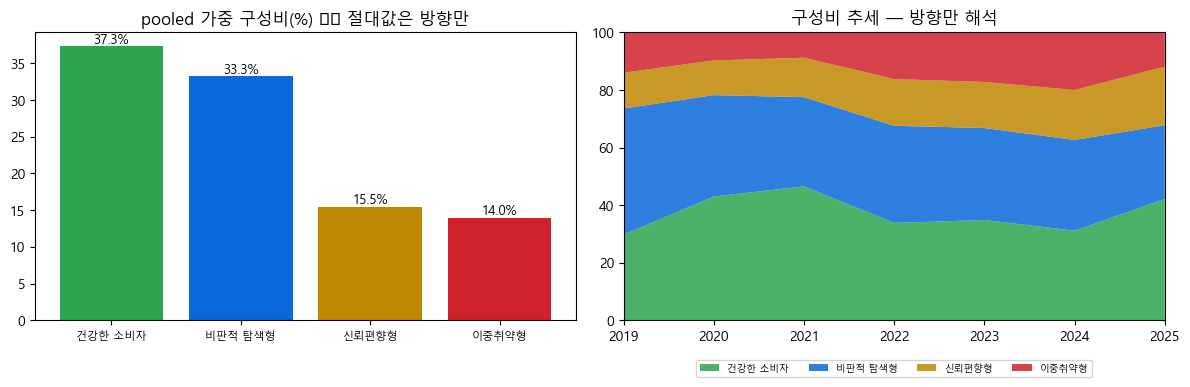

persona,건강한 소비자,비판적 탐색형,신뢰편향형,이중취약형
year,,,,
2019,29.8,43.8,12.4,14.0
2020,43.0,35.2,12.1,9.7
2021,46.5,31.0,13.7,8.8
2022,33.8,33.8,16.2,16.2
2023,34.8,32.0,16.0,17.2
2024,31.1,31.5,17.4,20.0
2025,42.2,25.6,20.4,11.9


In [2]:
pdf = pd.DataFrame({"year": panel["year"], "persona": persona, "w": W}).dropna(subset=["persona"])
pool_share = pdf.groupby("persona")["w"].sum()
pool_share = (pool_share / pool_share.sum() * 100)[ORDER]
share_y = pdf.groupby(["year", "persona"])["w"].sum().unstack(fill_value=0)
share_y = (share_y.div(share_y.sum(axis=1), axis=0) * 100)[ORDER]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
axes[0].bar(ORDER, pool_share.values, color=[COLORS[l] for l in ORDER])
for i, l in enumerate(ORDER):
    axes[0].text(i, pool_share[l] + 0.4, f"{pool_share[l]:.1f}%", ha="center", fontsize=9.5)
axes[0].set_title("pooled 가중 구성비(%) ⚠️ 절대값은 방향만")
axes[0].tick_params(axis="x", labelsize=8)
axes[1].stackplot(share_y.index, [share_y[c] for c in ORDER], labels=ORDER,
                  colors=[COLORS[c] for c in ORDER], alpha=0.85)
axes[1].set_ylim(0, 100); axes[1].margins(x=0)
axes[1].set_title("구성비 추세 — 방향만 해석")
axes[1].legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
fig.tight_layout(); plt.show()
share_y.round(1)

## **3. [실행] 인구 프로파일 전수 — 연령·성별·학력·소득**

**[시각화] 연령 분포** — 유형별 가중 연령 분포(핵심 대비 축). 표는 4유형 × 인구 4특성의 가중 프로파일 전수.

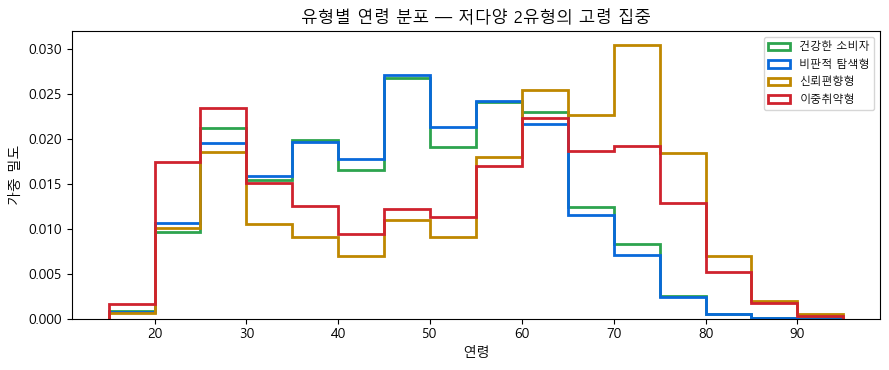

,건강한 소비자,비판적 탐색형,신뢰편향형,이중취약형
가중 구성비(%),37.3,33.3,15.5,14.0
평균연령(세),47.2,46.9,55.9,50.6
60세+ 비중(%),23.5,21.7,53.1,40.1
여성 비중(%),47.4,45.7,61.3,56.2
대재이상 비중(%),53.0,53.0,30.4,41.6
소득 상위밴드(5~7) 비중(%),62.9,60.2,41.3,45.8


In [3]:
age = pd.to_numeric(panel["age"], errors="coerce")
edu = pd.to_numeric(panel["edu"], errors="coerce")
sex = pd.to_numeric(panel["sex"], errors="coerce")
inc = pd.to_numeric(panel["income_band7"], errors="coerce")

rows = {}
for lab in ORDER:
    mm = persona == lab
    ww = W[mm]
    rows[lab] = {
        "가중 구성비(%)": round(float(pool_share[lab]), 1),
        "평균연령(세)": round(nf.wmean(age[mm], ww), 1),
        "60세+ 비중(%)": round(nf.wmean((age[mm] >= 60).astype(float), ww) * 100, 1),
        "여성 비중(%)": round(nf.wmean((sex[mm] == 2).astype(float), ww) * 100, 1),
        "대재이상 비중(%)": round(nf.wmean((edu[mm] >= 3).astype(float), ww) * 100, 1),
        "소득 상위밴드(5~7) 비중(%)": round(nf.wmean((inc[mm] >= 5).astype(float), ww) * 100, 1),
    }
demo = pd.DataFrame(rows)[ORDER]

fig, ax = plt.subplots(figsize=(9, 3.8))
for lab in ORDER:
    mm = (persona == lab) & age.notna()
    ax.hist(age[mm], bins=np.arange(15, 100, 5), weights=W[mm], density=True,
            histtype="step", lw=2, color=COLORS[lab], label=lab)
ax.set_xlabel("연령"); ax.set_ylabel("가중 밀도")
ax.set_title("유형별 연령 분포 — 저다양 2유형의 고령 집중")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()
demo

**관찰**: 저다양 2유형(신뢰편향형·이중취약형)은 평균연령과 60세+ 비중이 고다양 2유형보다 전 쌍 비교에서 일관되게 높으며, 학력(대재이상)·상위 소득 비중은 낮다 — 다양성 격차가 인구 구조와 강하게 얽혀 있다. `28`·`30` §7-3의 연령 정구배(고령 고신뢰)가 신뢰편향형의 높은 연령에서도 재확인된다.

## **4. [실행] 매체 프로파일 전수 — 고정풀 8 + 신설 3**

**[시각화] 확장 히트맵** — F6(고정풀 8)에 신설 3매체(2023+ 구간 가중)를 덧붙인 4×11. 셀 = 가중 이용률(%).

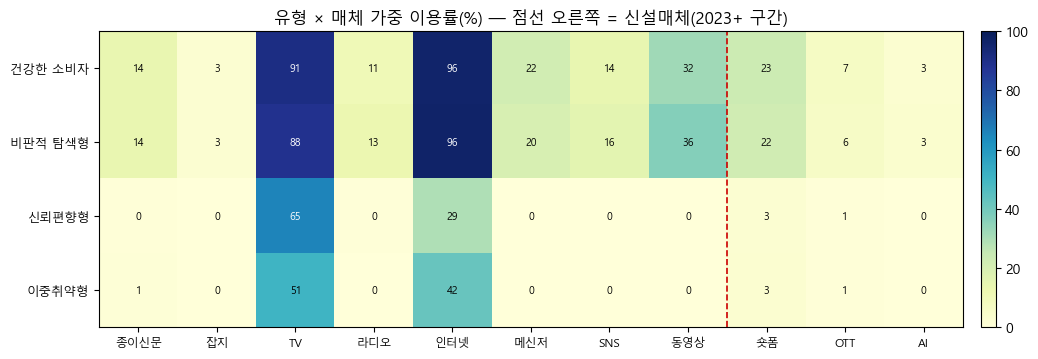

,종이신문,잡지,TV,라디오,인터넷,메신저,SNS,동영상,숏폼,OTT,AI
건강한 소비자,13.8,2.7,90.8,10.9,95.9,21.6,14.4,31.8,23.2,6.5,3.0
비판적 탐색형,13.7,2.7,88.3,12.9,96.3,19.9,15.7,36.5,22.2,6.0,3.2
신뢰편향형,0.4,0.0,65.5,0.4,29.0,0.1,0.0,0.1,2.7,0.7,0.0
이중취약형,0.9,0.0,50.7,0.3,41.9,0.0,0.0,0.3,2.9,0.5,0.3


In [4]:
USE8 = list(hz.FIXED_POOL8)
NEW3 = list(hz.USE_NEW_MEDIA)
KR = {"use_paper": "종이신문", "use_magazine": "잡지", "use_tv": "TV", "use_radio": "라디오",
      "use_internet": "인터넷", "use_messenger": "메신저", "use_sns": "SNS", "use_video": "동영상",
      "use_short": "숏폼", "use_ott": "OTT", "use_ai": "AI"}
mm_new = panel["year"] >= 2023
mat = []
for lab in ORDER:
    mm = persona == lab
    row = [nf.wmean(pd.to_numeric(panel[c], errors="coerce")[mm], W[mm]) * 100 for c in USE8]
    row += [nf.wmean(pd.to_numeric(panel[c], errors="coerce")[mm & mm_new], W[mm & mm_new]) * 100
            for c in NEW3]
    mat.append(row)
prof = pd.DataFrame(mat, index=ORDER, columns=[KR[c] for c in USE8 + NEW3])

fig, ax = plt.subplots(figsize=(10.5, 3.7))
im = ax.imshow(prof.values, cmap="YlGnBu", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(prof.shape[1])); ax.set_xticklabels(prof.columns, fontsize=8.5)
ax.set_yticks(range(4)); ax.set_yticklabels(ORDER, fontsize=9)
for i in range(4):
    for j in range(prof.shape[1]):
        v = prof.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                color="white" if v > 55 else "black")
ax.axvline(7.5, color="#c00", lw=1.2, ls="--")
ax.set_title("유형 × 매체 가중 이용률(%) — 점선 오른쪽 = 신설매체(2023+ 구간)")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
fig.tight_layout(); plt.show()
prof.round(1)

## **5. [발견] 개입 타깃의 특정 — 인구와 매체가 같은 곳을 가리킨다**

두 프로파일이 교차 특정하는 것: **저다양 2유형 = 고령 + TV 단일 채널**. 신뢰편향형은 TV를 믿고 그것만 보며(고신뢰·저다양), 이중취약형은 그마저 신뢰가 낮다(저신뢰·저다양). 신설매체(숏폼·OTT)에서도 두 유형은 거의 0 — 디지털 전환이 이 집단을 비껴간다. 따라서 "신뢰 회복 캠페인"보다 **매체 레퍼토리 확장 개입**(다양성 노출)이 이 타깃에 정합하다는 것이 보고서 5.2·7.1절 제안의 근거다. 단, 인과 주장이 아니라 표적 식별이다 — 저다양이 고령의 결과인지 원인인지는 이 설계로 답할 수 없다.

## **6. [입증] 검증 셀**

In [5]:
# (a) 저다양 2유형 최대 매체 = TV (F6·31 §6(d)와 동일 판정, 신설 포함 확장에서도)
for lab in ["신뢰편향형", "이중취약형"]:
    assert prof.loc[lab].idxmax() == "TV", prof.loc[lab].idxmax()
print("(a) 저다양 2유형 최대 매체 = TV (11매체 확장에서도) PASS")

# (b) 고령 집중 — 저다양 2유형이 평균연령·60세+ 비중 모두에서 고다양 2유형을 전 쌍 상회(방향)
for lo_lab in ["신뢰편향형", "이중취약형"]:
    for hi_lab in ["건강한 소비자", "비판적 탐색형"]:
        assert demo.loc["평균연령(세)", lo_lab] > demo.loc["평균연령(세)", hi_lab], (lo_lab, hi_lab)
        assert demo.loc["60세+ 비중(%)", lo_lab] > demo.loc["60세+ 비중(%)", hi_lab], (lo_lab, hi_lab)
gap_age = min(demo.loc["평균연령(세)", ["신뢰편향형", "이중취약형"]]) -           max(demo.loc["평균연령(세)", ["건강한 소비자", "비판적 탐색형"]])
print(f"(b) 고령 집중: 평균연령·60세+ 비중 전 쌍(2×2) 상회 — 최소 격차 {gap_age:.1f}세 PASS")

# (c) 신설매체 부재 — 저다양 2유형의 숏폼·OTT ≤ 고다양 2유형의 1/3
for med in ["숏폼", "OTT"]:
    lo = max(prof.loc["신뢰편향형", med], prof.loc["이중취약형", med])
    hi = min(prof.loc["건강한 소비자", med], prof.loc["비판적 탐색형", med])
    assert lo <= hi / 3, (med, lo, hi)
print("(c) 신설매체(숏폼·OTT): 저다양 ≤ 고다양의 1/3 — 디지털 전환 배제 PASS")

# (d) 구성비 정합 — 연도 구성비 합 100 · pooled 합 100
assert np.allclose(share_y.sum(axis=1), 100) and abs(pool_share.sum() - 100) < 1e-6
print("(d) 구성비 합 100% (연도별·pooled) PASS")
print("\n검증 (a)~(d) 전부 PASS")

(a) 저다양 2유형 최대 매체 = TV (11매체 확장에서도) PASS
(b) 고령 집중: 평균연령·60세+ 비중 전 쌍(2×2) 상회 — 최소 격차 3.4세 PASS
(c) 신설매체(숏폼·OTT): 저다양 ≤ 고다양의 1/3 — 디지털 전환 배제 PASS
(d) 구성비 합 100% (연도별·pooled) PASS

검증 (a)~(d) 전부 PASS


## **7. 종합**

### **연구질문 답**

- **Q1** — 4유형은 인구학적으로 일관되게 갈린다: 저다양 2유형은 평균연령·60세+ 비중이 전 쌍 비교에서 높고, 학력·소득은 낮다(§3) — 유형이 통계적 구획이 아니라 사회적 실체와 겹친다.
- **Q2** — 매체가 유형의 정의를 되비춘다: 고다양 2유형은 TV+인터넷 축의 넓은 레퍼토리, 저다양 2유형은 TV 단일 채널에 신설매체 거의 0(§4).
- **Q3** — §6의 (a)~(c) 세 assert가 그 근거다: TV 최대·연령/60세+ 전 쌍 상회·신설매체 1/3 이하 — 보고서 5.2절 문장 하나하나가 검증 셀에 대응한다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 규모·구성비 추세 [시각화] | 방향 확인 |
| 3 | 인구 프로파일 전수 [시각화] | 고령 집중 |
| 4 | 매체 프로파일 8+3 [시각화] | TV 편중 |
| 5 | 개입 타깃 특정 | 근거 확정 |
| 6 | 일괄 assert | **PASS** |

**다음**: `09`(B2C 진단 규칙 설계) — 이 프로파일이 곧 웹데모의 처방 문구가 된다.